In [1]:
import sys
sys.path.append("../ext/equi-rl-for-pomdps")
from rgbd_sym.api import make_env
import argparse
import numpy as np
from rgbd_sym.tool.plt import use_backend

from rgbd_sym.tool.sym import local_sym_step
from rgbd_sym.tool.depth import get_intrinsic_matrix, projection_matrix_to_K
import time
from copy import deepcopy
# use_backend('tkagg')

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [3]:
sym_step_idx = 5
size = 84

args = {}

args['action_delta_pos'] = 0.05
args['action_delta_rot'] = np.pi / 8
args['pc_x_center'] = 0.0
args['pc_y_center'] = 0.0
args['pc_z_center'] = 0.75
args['pc_range'] = 0.8
args['voxel_res'] = 84
args['depth_real_min'] = 0
args['depth_real_max'] = 1
args['depth_upsample'] = 6
args['out_image_type'] = 'depth'
args['out_background_encoding'] = 255

In [26]:
from rgbd_sym.tool.common import getT, TxT, invT, T2Euler, scale_arr
from rgbd_sym.tool.sym import action2transformdict
from rgbd_sym.tool.plt import plot_img
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow, subplot, axis, cm, show

def Ts2actions(
    origin_T,
    interval_Ts,
    action_delta_pos,
    interval_gripper_states,
    interval_oris,
):
    # print(origin_T)
    actions = []
    prv_T = origin_T[:3,3]
    exceed= False
    for i in range(len(interval_Ts)):
        delta_T = interval_Ts[i][:3, 3] - prv_T
        a_p = scale_arr(delta_T, -action_delta_pos, action_delta_pos, -1, 1)
        a_p[0] = -a_p[0]
        a_p[1] = -a_p[1]
        # a_p[2] = -a_p[2]
        # assert np.all(a_p) >= -1 and np.all(a_p) <=1, a_p
        # assert a_o >= -1 and a_o <= 1, f"ori, {o}, max, {action_delta_rot}, i {i}"
        if  not (np.all(a_p) >= -1 and np.all(a_p) <=1):
            exceed = True
            a_p = np.clip(a_p, -1, 1)
        a = np.array(
            [
                interval_gripper_states[i],
                a_p[0],
                a_p[1],
                a_p[2],
                interval_oris[i],
            ]
        )
        actions.append(a)
        # print(prv_T)
        prv_T = interval_Ts[i][:3, 3]
    return actions, exceed

def actions2Ts(
    actions,
    action_delta_pos,
    action_delta_rot,
):
    trajTs = []
    _actions = actions
    _actions = [np.zeros(5)] + _actions
    T_dict = None
    
    for action in _actions:
        delta_T_dict = action2transformdict(
            action,
            reverse=False,
            delta_pos=action_delta_pos,
            delta_rot=action_delta_rot,
        )
        if T_dict is None:
            T_dict = delta_T_dict
        else:
            T_dict = {k: TxT([delta_T_dict[k], v]) for k, v in T_dict.items()}
        trajTs.append(T_dict)

    trajTs = [v["object2"] for v in trajTs]
    return trajTs


def plot_traj(
    point_mats,
    elev=45,
    azim=45,
    roll=45,
):
    fig = plt.figure()
    ax = plt.axes(projection="3d")
    # ax.axes.set_xlim3d(left=range_min[0], right=range_max[0])
    # ax.axes.set_ylim3d(bottom=range_min[1], top=range_max[1])
    # ax.axes.set_zlim3d(bottom=range_min[2], top=range_max[2])

    ax.set_xlabel("$X$")
    ax.set_ylabel("$Y$")
    ax.set_zlabel("$Z$")
    # if legend_txt == None:
    pc_min = None
    pc_max = None
    for point_mat in point_mats:
        pc = point_mat['mat']
        args = point_mat.copy()
        args.pop('mat', None)
        ax.plot3D(
            pc[:, 0].tolist(),
            pc[:, 1].tolist(),
            pc[:, 2].tolist(),
            **args,
        )
        _min = np.min(pc, axis=0)
        _max = np.max(pc, axis=0)
        pc_min = _min if pc_min is None else np.minimum(pc_min, _min)
        pc_max = _max if pc_max is None else np.maximum(pc_max, _max)
    _range = np.max(pc_max- pc_min)

    plt.legend(loc="best")
    ax.view_init(elev=elev, azim=azim, roll=roll)
    ax.axes.set_xlim3d(left=pc_min[0], right=pc_min[0]+_range)
    ax.axes.set_ylim3d(bottom=pc_min[1], top=pc_min[1]+_range)
    ax.axes.set_zlim3d(bottom=pc_min[2], top=pc_min[2]+_range)
    show()

robot id None
K [[59.98221231  0.         42.        ]
 [ 0.         59.98221231 42.        ]
 [ 0.          0.          1.        ]]


/home/ben/miniconda3/envs/rgbd-sym/lib/python3.9/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


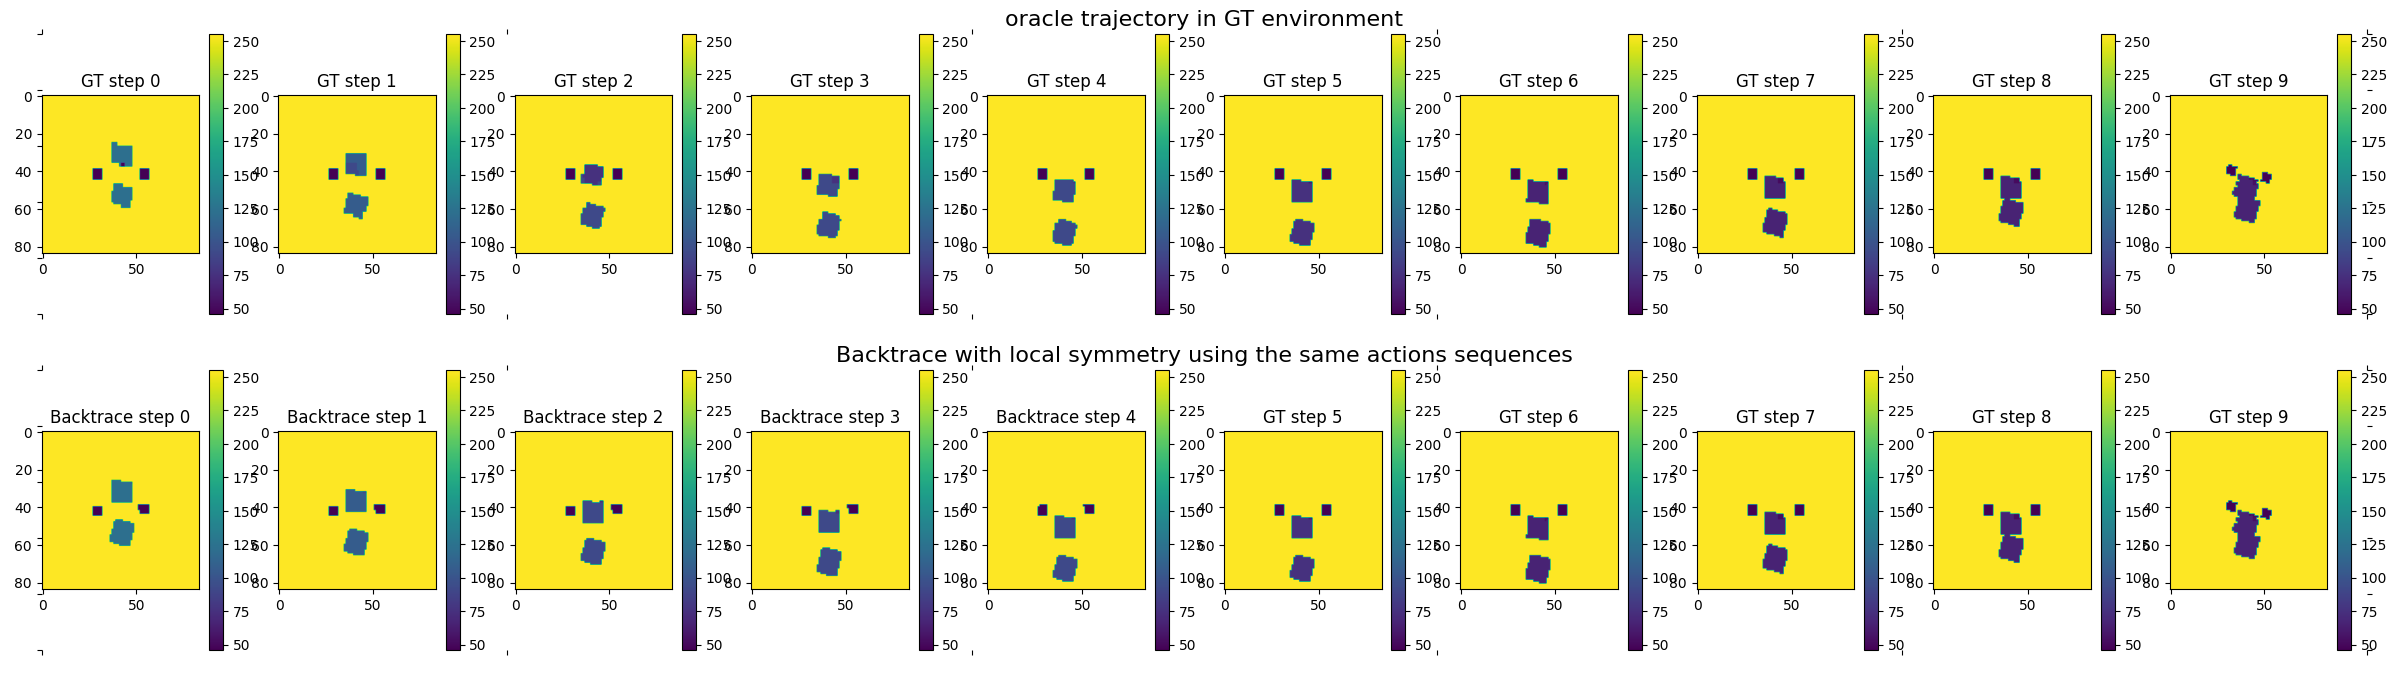

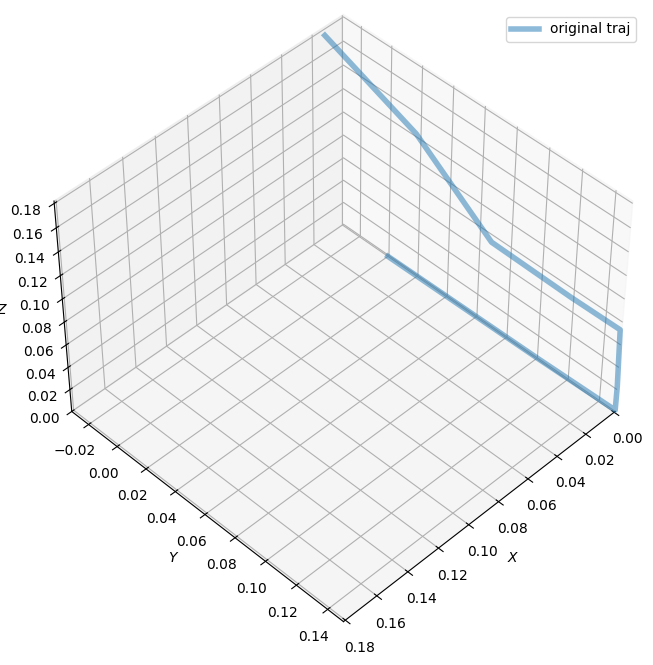

origin actions [array([ 1.        ,  0.22190205, -1.        , -1.        , -0.01591283]), array([ 1.        ,  0.01055113, -1.        , -1.        ,  0.03969749]), array([ 1.        ,  0.00519506, -1.        , -0.03877851,  0.03622442]), array([ 1.00000000e+00,  5.80779480e-03, -6.20939028e-01, -3.38882208e-04,
        3.69848250e-02]), array([ 1.        ,  0.00505584, -0.01778866, -1.        ,  0.03315243]), array([ 1.00000000e+00, -1.55073701e-03,  2.57833723e-04, -4.27865186e-01,
       -1.85489784e-03]), array([ 1.        , -0.00163009,  1.        , -0.0267821 , -0.00555676]), array([ 1.00000000e+00, -5.73327447e-03,  1.00000000e+00, -3.02480161e-04,
       -3.79938066e-02]), array([ 1.00000000e+00, -6.09328652e-03,  1.00000000e+00, -2.66879797e-06,
       -3.69427930e-02])]
origin points [[-0.00000000e+00 -0.00000000e+00  0.00000000e+00]
 [-3.04664326e-04  5.00000000e-02  1.33439898e-07]
 [-5.91328049e-04  1.00000000e-01  1.52574480e-05]
 [-6.72832585e-04  1.50000000e-01  1.354362

In [18]:
env, env_config = make_env(tags=['block_pull', "no_clutch"], seed=0)
obs = env.reset()
proj_matrix = env.get_projection_matrix()
K = projection_matrix_to_K(proj_matrix, image_size=size)
print("K", K)
# generate ground truth trajectory
origin_actions = []
imgs1_meta = [obs]
done = False
while not done:
    action = env.pull_movable()
    origin_actions.append(action)
    obs, reward, done, info = env.step(action)
    imgs1_meta.append(obs)
origin_depth_image_traj = []
for i in range(len(imgs1_meta)):
    origin_depth_image_traj.append(local_sym_step(imgs1_meta[i]['depth'],
                                                  imgs1_meta[i]['mask'], [],
                                                  K=K,
                                                  **args)[0])

oa = deepcopy(origin_actions)
# generate symmetric trajectry with backtrace
start_depth_dict = imgs1_meta[sym_step_idx]['depth']
start_mask_dict = imgs1_meta[sym_step_idx]['mask']
sym_actions = [a for a in oa[:sym_step_idx]]
start = time.time()

sym_depth_image_traj = local_sym_step(
    start_depth_dict, 
    start_mask_dict, 
    sym_actions, 
    K=K, 
    reverse=True,
    **args)

sym_depth_image_traj.extend(origin_depth_image_traj[sym_step_idx+1:])
sym_actions.extend(oa[sym_step_idx:])
imgss = []
imgss.append([{"image": v, "title": f"GT step {i}"} for i, v in enumerate(origin_depth_image_traj)])
imgss.append([{"image": v, "title": f"GT step {i}" if i>=sym_step_idx else f"Backtrace step {i}"} for i, v in enumerate(sym_depth_image_traj)])
plt.rcParams['figure.figsize'] = [30, 8]
plot_img(imgss, big_axes_title=["oracle trajectory in GT environment", "Backtrace with local symmetry using the same actions sequences",])

trajTs = actions2Ts(
    [-a for a in reversed(oa)],
    action_delta_pos=args["action_delta_pos"],
    action_delta_rot=args["action_delta_rot"],
    # reverse=True,
)
points_mats = []
pc_mat = {}
pc_mat['mat'] = np.array([[t[0][3], t[1][3], t[2][3]] for t in trajTs])
pc_mat['linewidth'] = 4
pc_mat['alpha'] =0.5   
pc_mat['label'] =f"original traj"   
points_mats.append(pc_mat)
plot_traj(points_mats, elev=45, azim=45, roll=0)
print("origin actions", oa)
print("origin points", pc_mat['mat'])

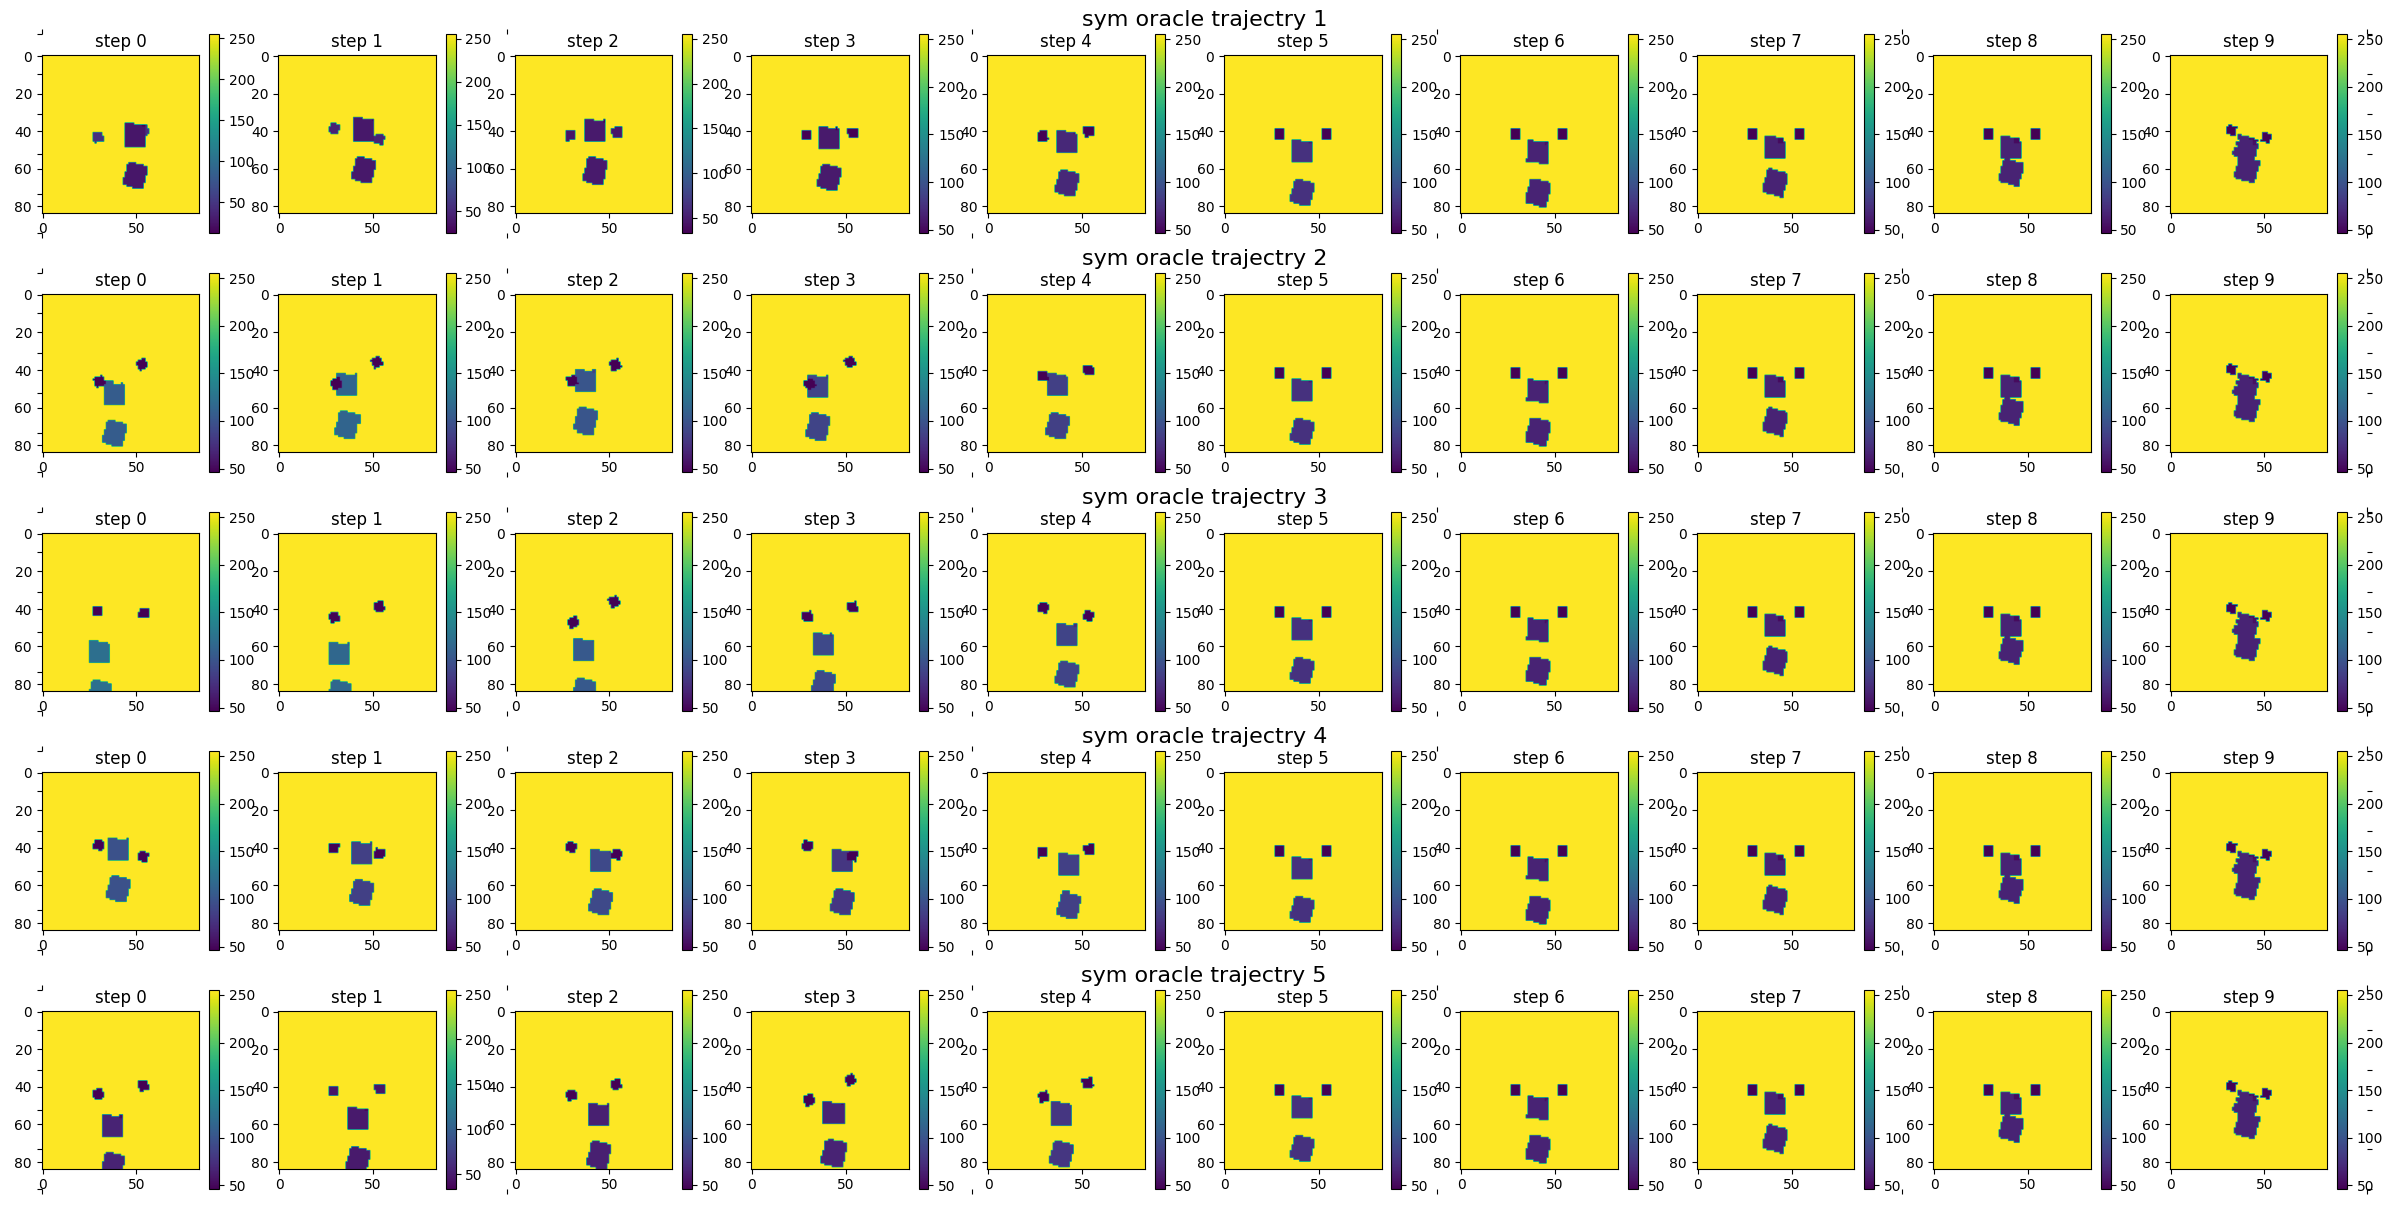

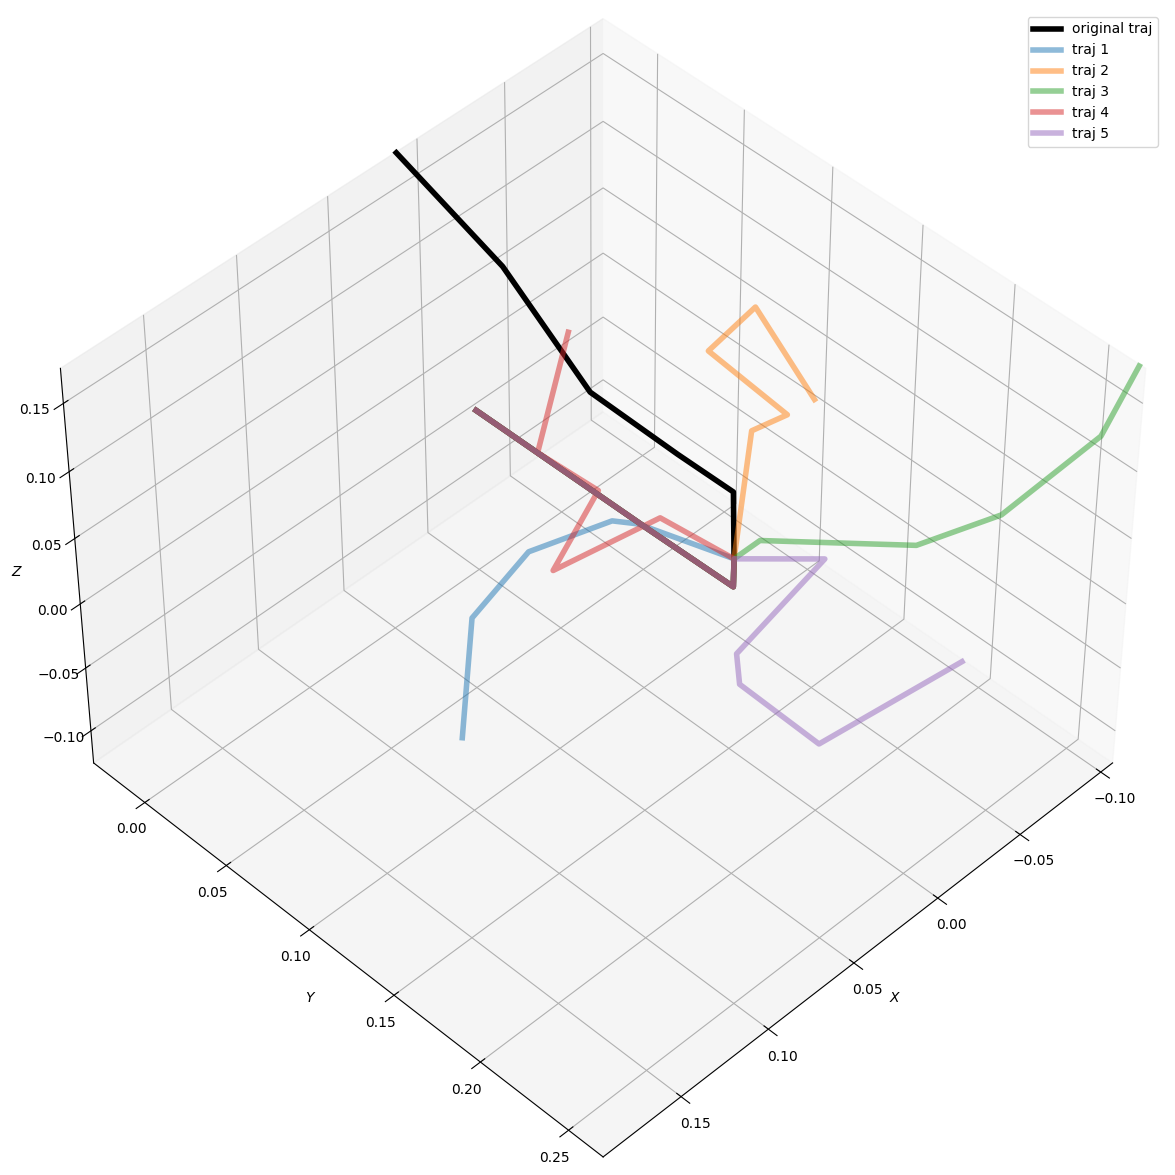

In [16]:

traj_nums = 5
sym_trajs = []
sym_actions_fulls = []
for i in range(traj_nums):
    oa = deepcopy(origin_actions)
    sym_actions = [a for a in oa[:sym_step_idx]]
    for k in range(len(sym_actions)):
        # sym_actions[0] = np.random.uniform(-1,1)
        sym_actions[k][1] = np.random.uniform(-1, 1)
        sym_actions[k][2] = np.random.uniform(-1, 1)
        sym_actions[k][3] = np.random.uniform(-1, 1)
        sym_actions[k][4] = np.random.uniform(-1, 1)
    

    sym_actions_full = deepcopy(sym_actions)
    sym_actions_full.extend(oa[sym_step_idx:])
    sym_actions_fulls.append(sym_actions_full)


    sym_depth_image_traj3 = local_sym_step(
        start_depth_dict, start_mask_dict, sym_actions, K=K, reverse=True, **args
    )
    sym_depth_image_traj3.extend(origin_depth_image_traj[sym_step_idx + 1 :])
    sym_trajs.append(
        [
            {"image": v, "title": f"step {j}"}
            for j, v in enumerate(sym_depth_image_traj3)
        ]
    )
plt.rcParams["figure.figsize"] = [30, 15]
plot_img(
    sym_trajs, big_axes_title=[f"sym oracle trajectry {i+1}" for i in range(traj_nums)]
)
points_mats = []

trajTs = actions2Ts(
    origin_actions,
    action_delta_pos=args["action_delta_pos"],
    action_delta_rot=args["action_delta_rot"],
    reverse=True,
)
points_mats = []
pc_mat = {}
pc_mat['mat'] = np.array([[t[0][3], t[1][3], t[2][3]] for t in trajTs])
pc_mat['linewidth'] = 4
pc_mat['alpha'] =1   
pc_mat['label'] =f"original traj"   
pc_mat['color'] = "k" 
points_mats.append(pc_mat)



for i, a in enumerate(sym_actions_fulls):
    trajTs = actions2Ts(
        a,
        action_delta_pos=args["action_delta_pos"],
        action_delta_rot=args["action_delta_rot"],
        reverse=True,
    )
    pc_mat = {}
    pc_mat['mat'] = np.array([[t[0][3], t[1][3], t[2][3]] for t in trajTs])
    pc_mat['linewidth'] = 4
    pc_mat['alpha'] =0.5   
    pc_mat['label'] =f"traj {i+1}"   
    points_mats.append(pc_mat)

plot_traj(points_mats, elev=45, azim=45, roll=0)

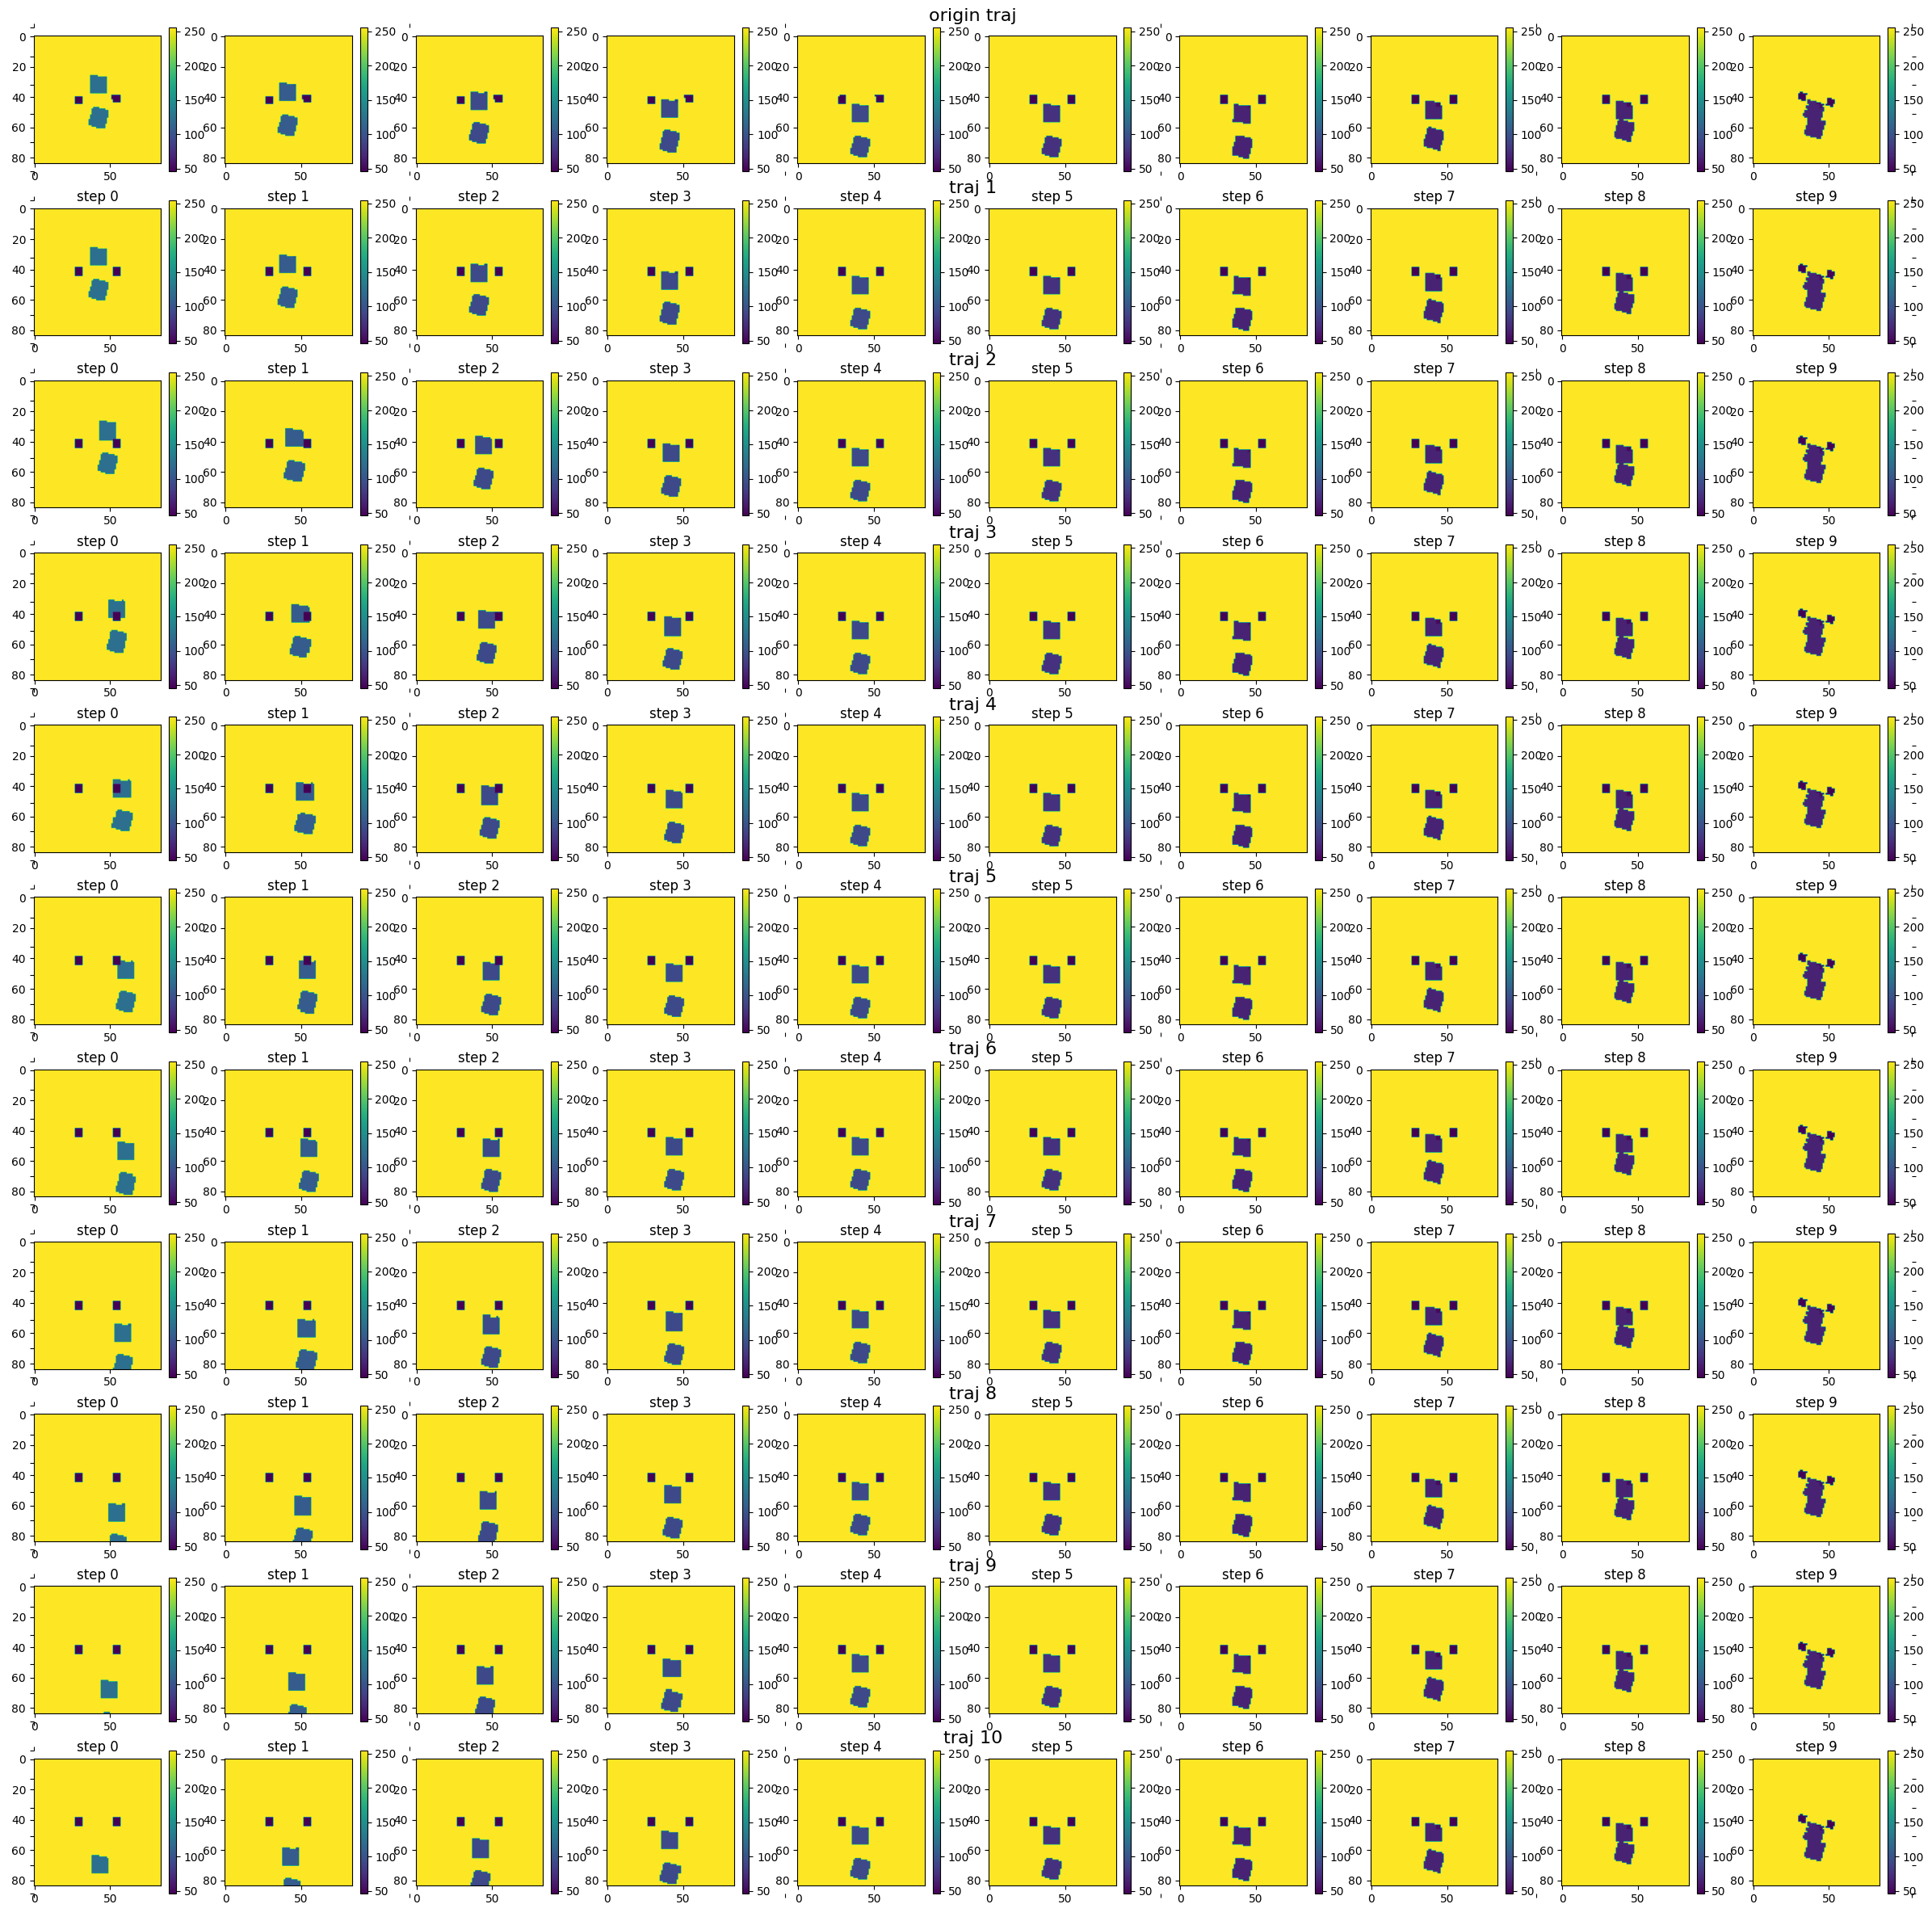

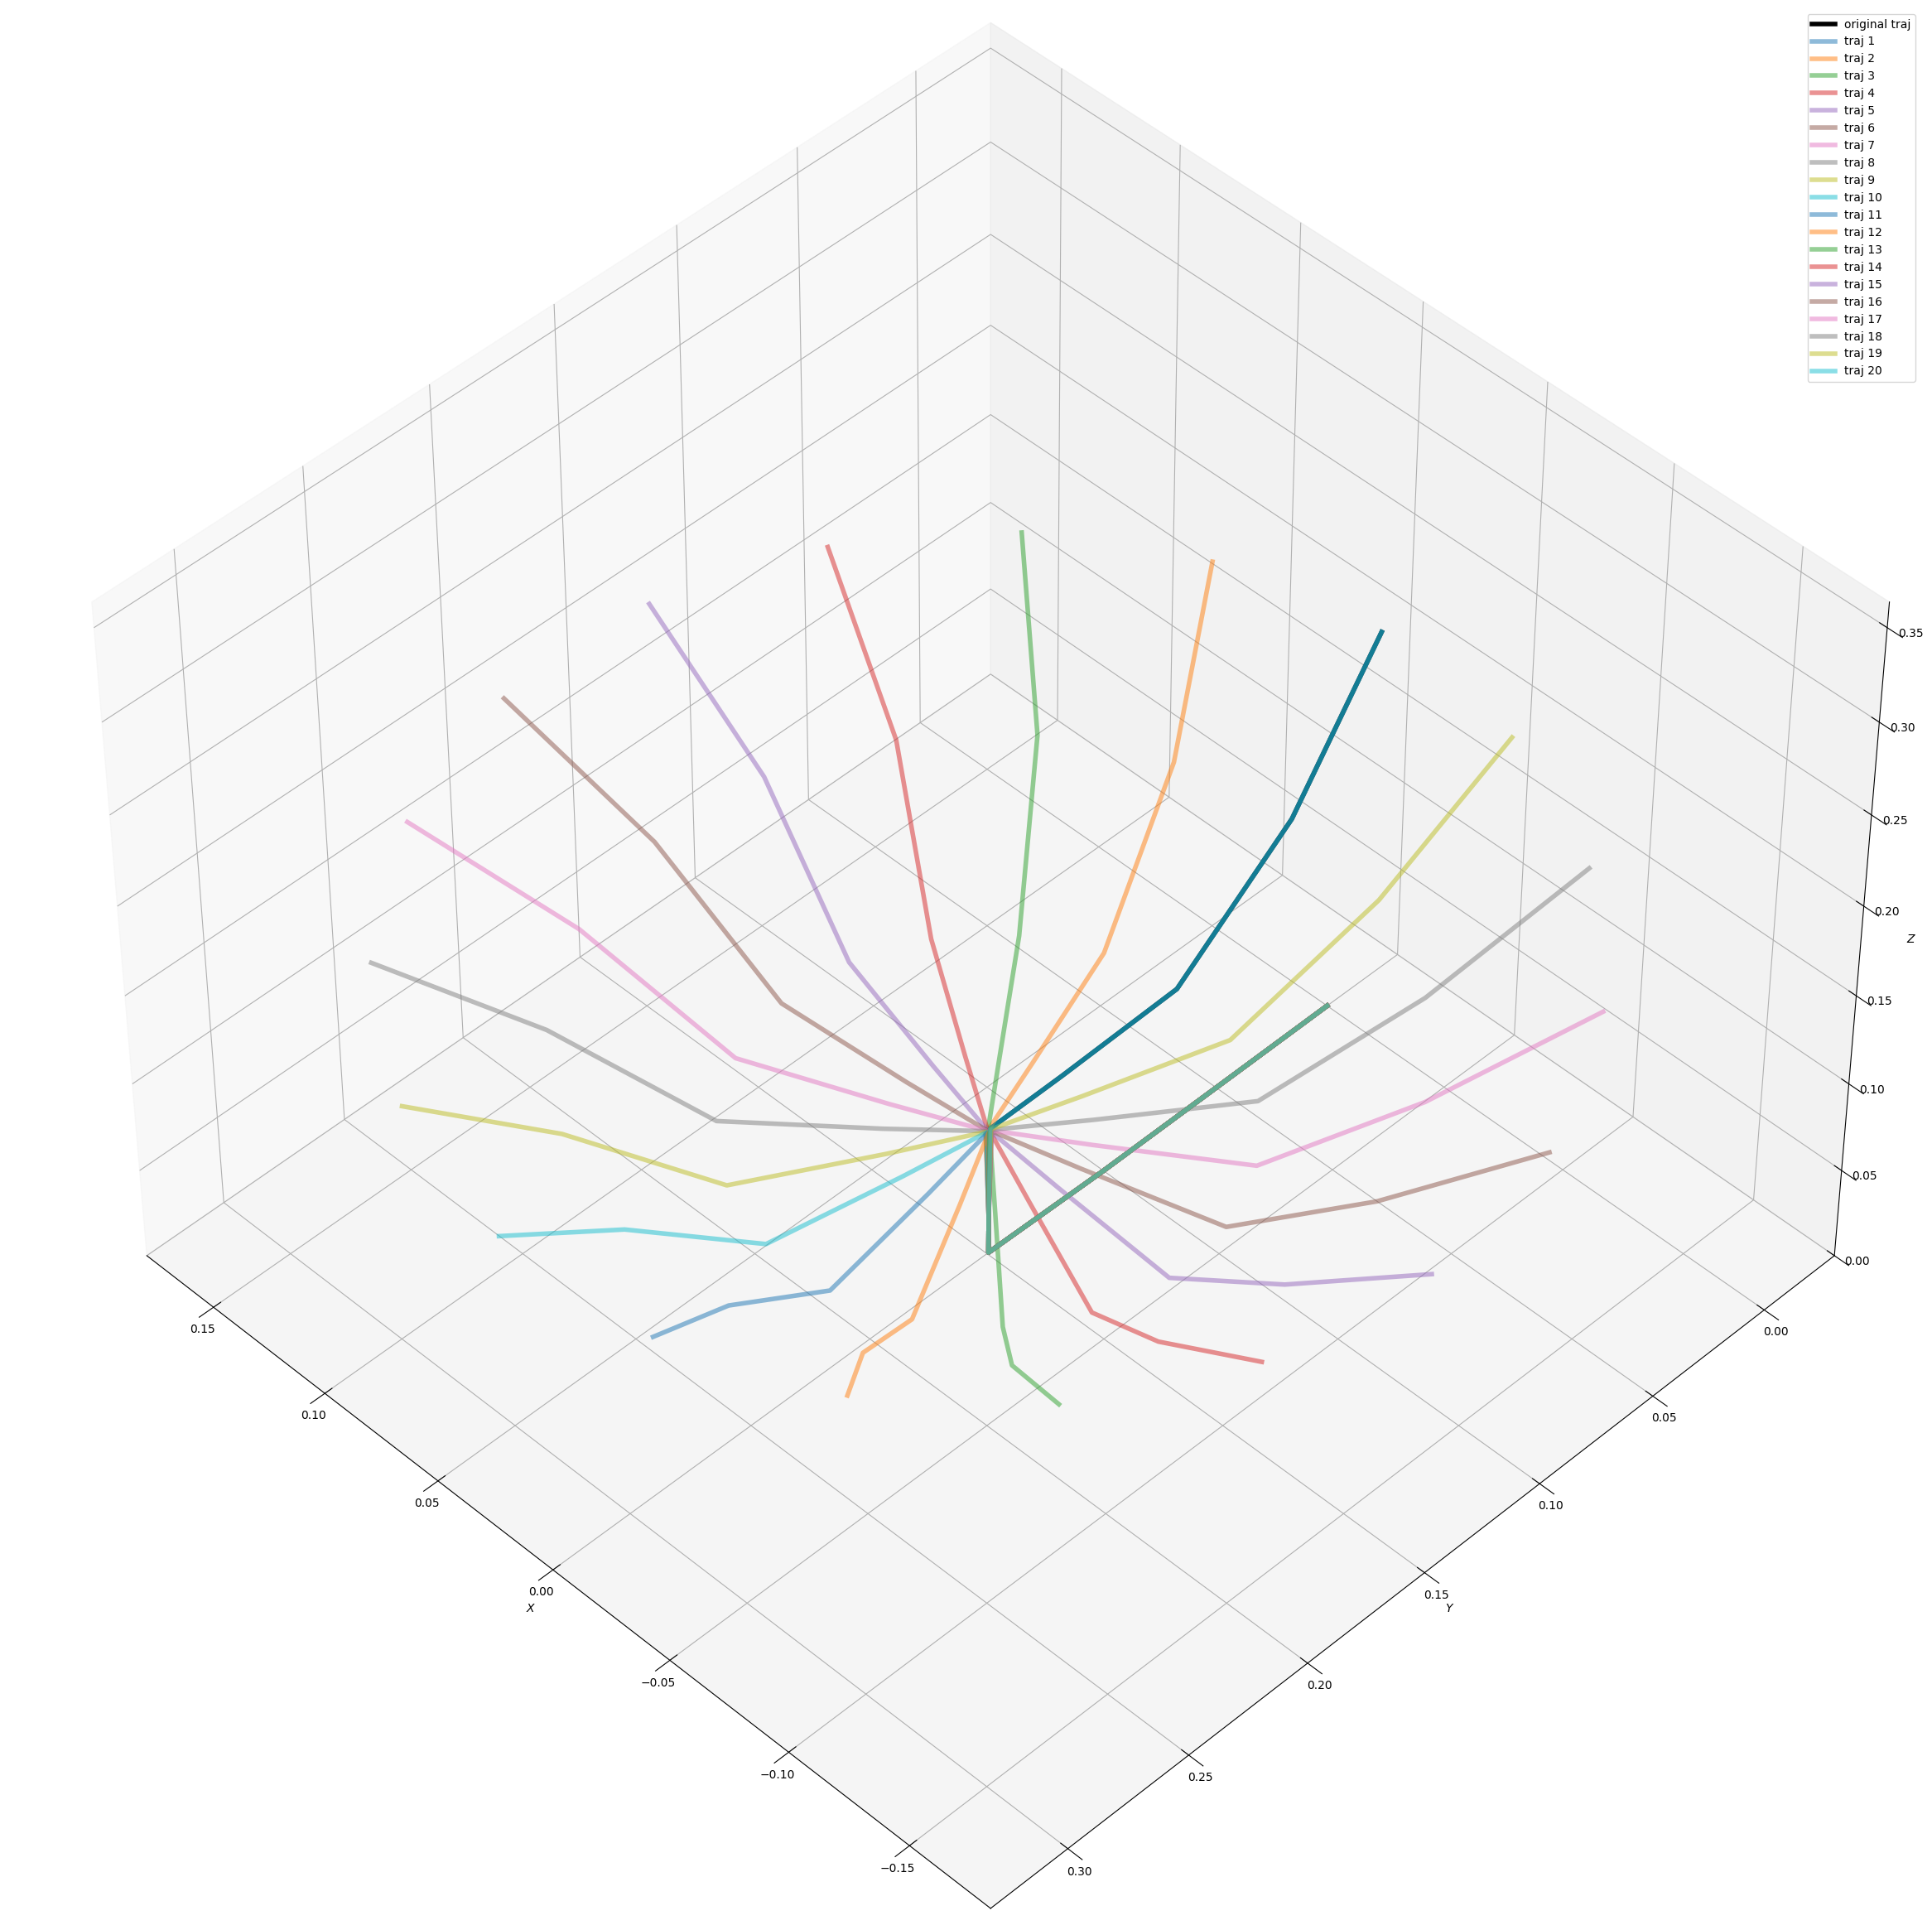

In [42]:
sym_trajs = []
sym_actions_fulls = []

oa = deepcopy(origin_actions)
trajTs = actions2Ts(
    [-a for a in reversed(origin_actions)],
    action_delta_pos=args["action_delta_pos"],
    action_delta_rot=args["action_delta_rot"],
)
traj_nums = 20
new_trajTss = []

angles = np.linspace(0, 360, num=traj_nums)
radius_ratio =1
height_ratio =1
screw_angle = 0

for traj_idx in range(traj_nums):
    new_trajTs = []
    start_idx = len(trajTs) - sym_step_idx - 1
    screw_cnt = 0
    for idx in range(len(trajTs)):
        if idx <= start_idx:
            new_trajTs.append(trajTs[idx].copy())
        else:
            origin_T = trajTs[start_idx].copy()
            current_T = trajTs[idx].copy()
            current_T[0:3, 3] = current_T[0:3, 3] - origin_T[0:3, 3]
            current_T[0:2, 3] = current_T[0:2, 3] * radius_ratio
            current_T[2, 3] = current_T[2, 3] * height_ratio
            deltaT = getT([0, 0, 0], [0, 0, angles[traj_idx] + screw_cnt * screw_angle], rot_type="euler")
            current_T = TxT([deltaT, current_T])
            current_T[0:3, 3] = current_T[0:3, 3] + origin_T[0:3, 3]
            new_trajTs.append(current_T)
            screw_cnt+=1
    new_trajTss.append(new_trajTs)


sym_trajs = [sym_depth_image_traj]
for new_trajTs in new_trajTss[:10]:
    _Ts = deepcopy(new_trajTs)
    # _Ts = [v for v in reversed(_Ts)]

    reverse_actions, exceed = Ts2actions(
        origin_T=_Ts[0],
        interval_Ts=_Ts[1:],
        action_delta_pos=args["action_delta_pos"],
        interval_gripper_states=np.zeros(len(_Ts[1:])),
        interval_oris=np.zeros(len(_Ts[1:])),
    )
    reverse_actions = [a for a in reversed(reverse_actions)]
    reverse_actions_old = [-a for a in origin_actions]
    for k in range(len(reverse_actions_old)):
        # sym_actions[0] = np.random.uniform(-1,1)
        if k>= sym_step_idx-1:
            reverse_actions[k][1] = reverse_actions_old[k][1]
            reverse_actions[k][2] =  reverse_actions_old[k][2]
            reverse_actions[k][3] =  reverse_actions_old[k][3]
        # sym_actions[k][4] = np.random.uniform(-1, 1)
    
    reverse_actions = [a for a in reversed(reverse_actions)]
    
    start_depth_dict = imgs1_meta[sym_step_idx]['depth']
    start_mask_dict = imgs1_meta[sym_step_idx]['mask']
    sym_depth_image_traj3 = local_sym_step(
        start_depth_dict, start_mask_dict, reverse_actions[len(reverse_actions)-sym_step_idx: ], K=K, reverse=False, **args
    )
    sym_depth_image_traj3 = [s for s in reversed(sym_depth_image_traj3)]
    sym_depth_image_traj3.extend(origin_depth_image_traj[sym_step_idx+1:])
    sym_trajs.append(
        [
            {"image": v, "title": f"step {j}"}
            for j, v in enumerate(sym_depth_image_traj3)
        ]
    )

points_mats = []

trajTs = actions2Ts(
    [-a for a in reversed(origin_actions)],
    action_delta_pos=args["action_delta_pos"],
    action_delta_rot=args["action_delta_rot"],
)
points_mats = []
pc_mat = {}
pc_mat["mat"] = np.array([[t[0][3], t[1][3], t[2][3]] for t in trajTs])
pc_mat["linewidth"] = 4
pc_mat["alpha"] = 1
pc_mat["label"] = f"original traj"
pc_mat["color"] = "k"
points_mats.append(pc_mat)

for i, new_trajTs in enumerate(new_trajTss):
    pc_mat = {}
    pc_mat["mat"] = np.array([[t[0][3], t[1][3], t[2][3]] for t in new_trajTs])
    pc_mat["linewidth"] = 4
    pc_mat["alpha"] = 0.5
    pc_mat["label"] = f"traj {i+1}"
    points_mats.append(pc_mat)

big_axes_title = ['origin traj']
big_axes_title.extend( [f"traj {i+1}" for i in range(len(sym_trajs)-1)])
plt.rcParams["figure.figsize"] = [30, 30]
plot_img(
    sym_trajs,
    big_axes_title=big_axes_title
)

plot_traj(points_mats, elev=45, azim=135, roll=0)

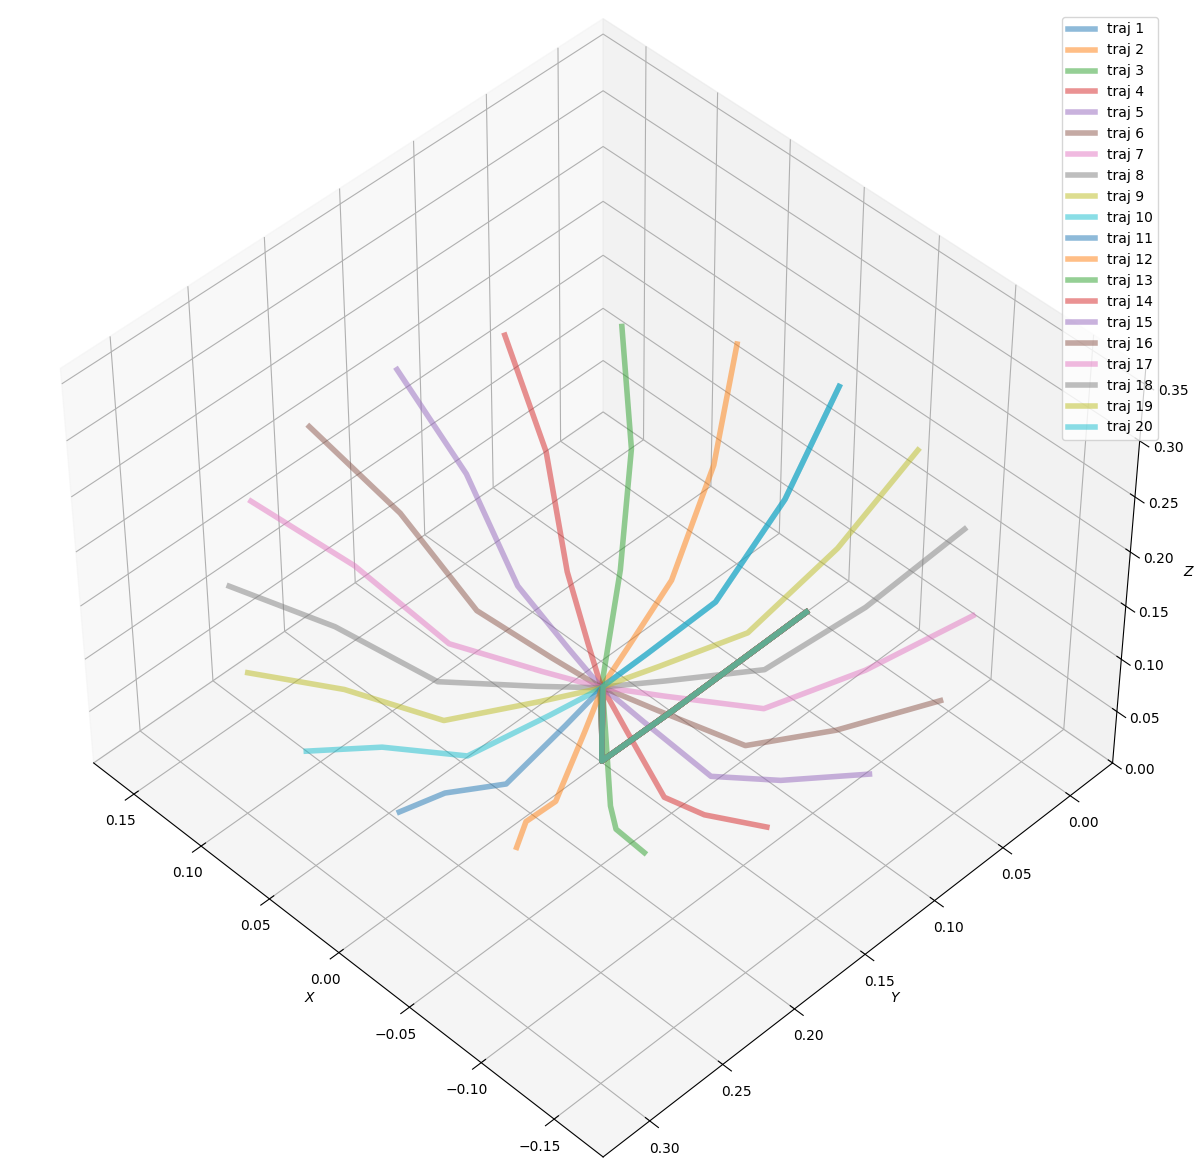

In [27]:
actionss = []
for new_trajTs in new_trajTss:
    actions, exceed = Ts2actions(
        origin_T=new_trajTs[0],
        interval_Ts=new_trajTs[1:],
        action_delta_pos=args["action_delta_pos"],
        interval_gripper_states=np.zeros(len(new_trajTs[1:])),
        interval_oris=np.zeros(len(new_trajTs[1:])),
    )
    # print(actions)
    actions = [v for v in reversed(actions)]
    actionss.append(actions)

points_mats = []
for i, a in enumerate(actionss):
    trajTs = actions2Ts(
        [v for v in reversed(a)],
        action_delta_pos=args["action_delta_pos"],
        action_delta_rot=args["action_delta_rot"],

    )
    pc_mat = {}
    pc_mat["mat"] = np.array([[t[0][3], t[1][3], t[2][3]] for t in trajTs])
    pc_mat["linewidth"] = 4
    pc_mat["alpha"] = 0.5
    pc_mat["label"] = f"traj {i+1}"
    points_mats.append(pc_mat)
plot_traj(points_mats, elev=45, azim=135, roll=0)

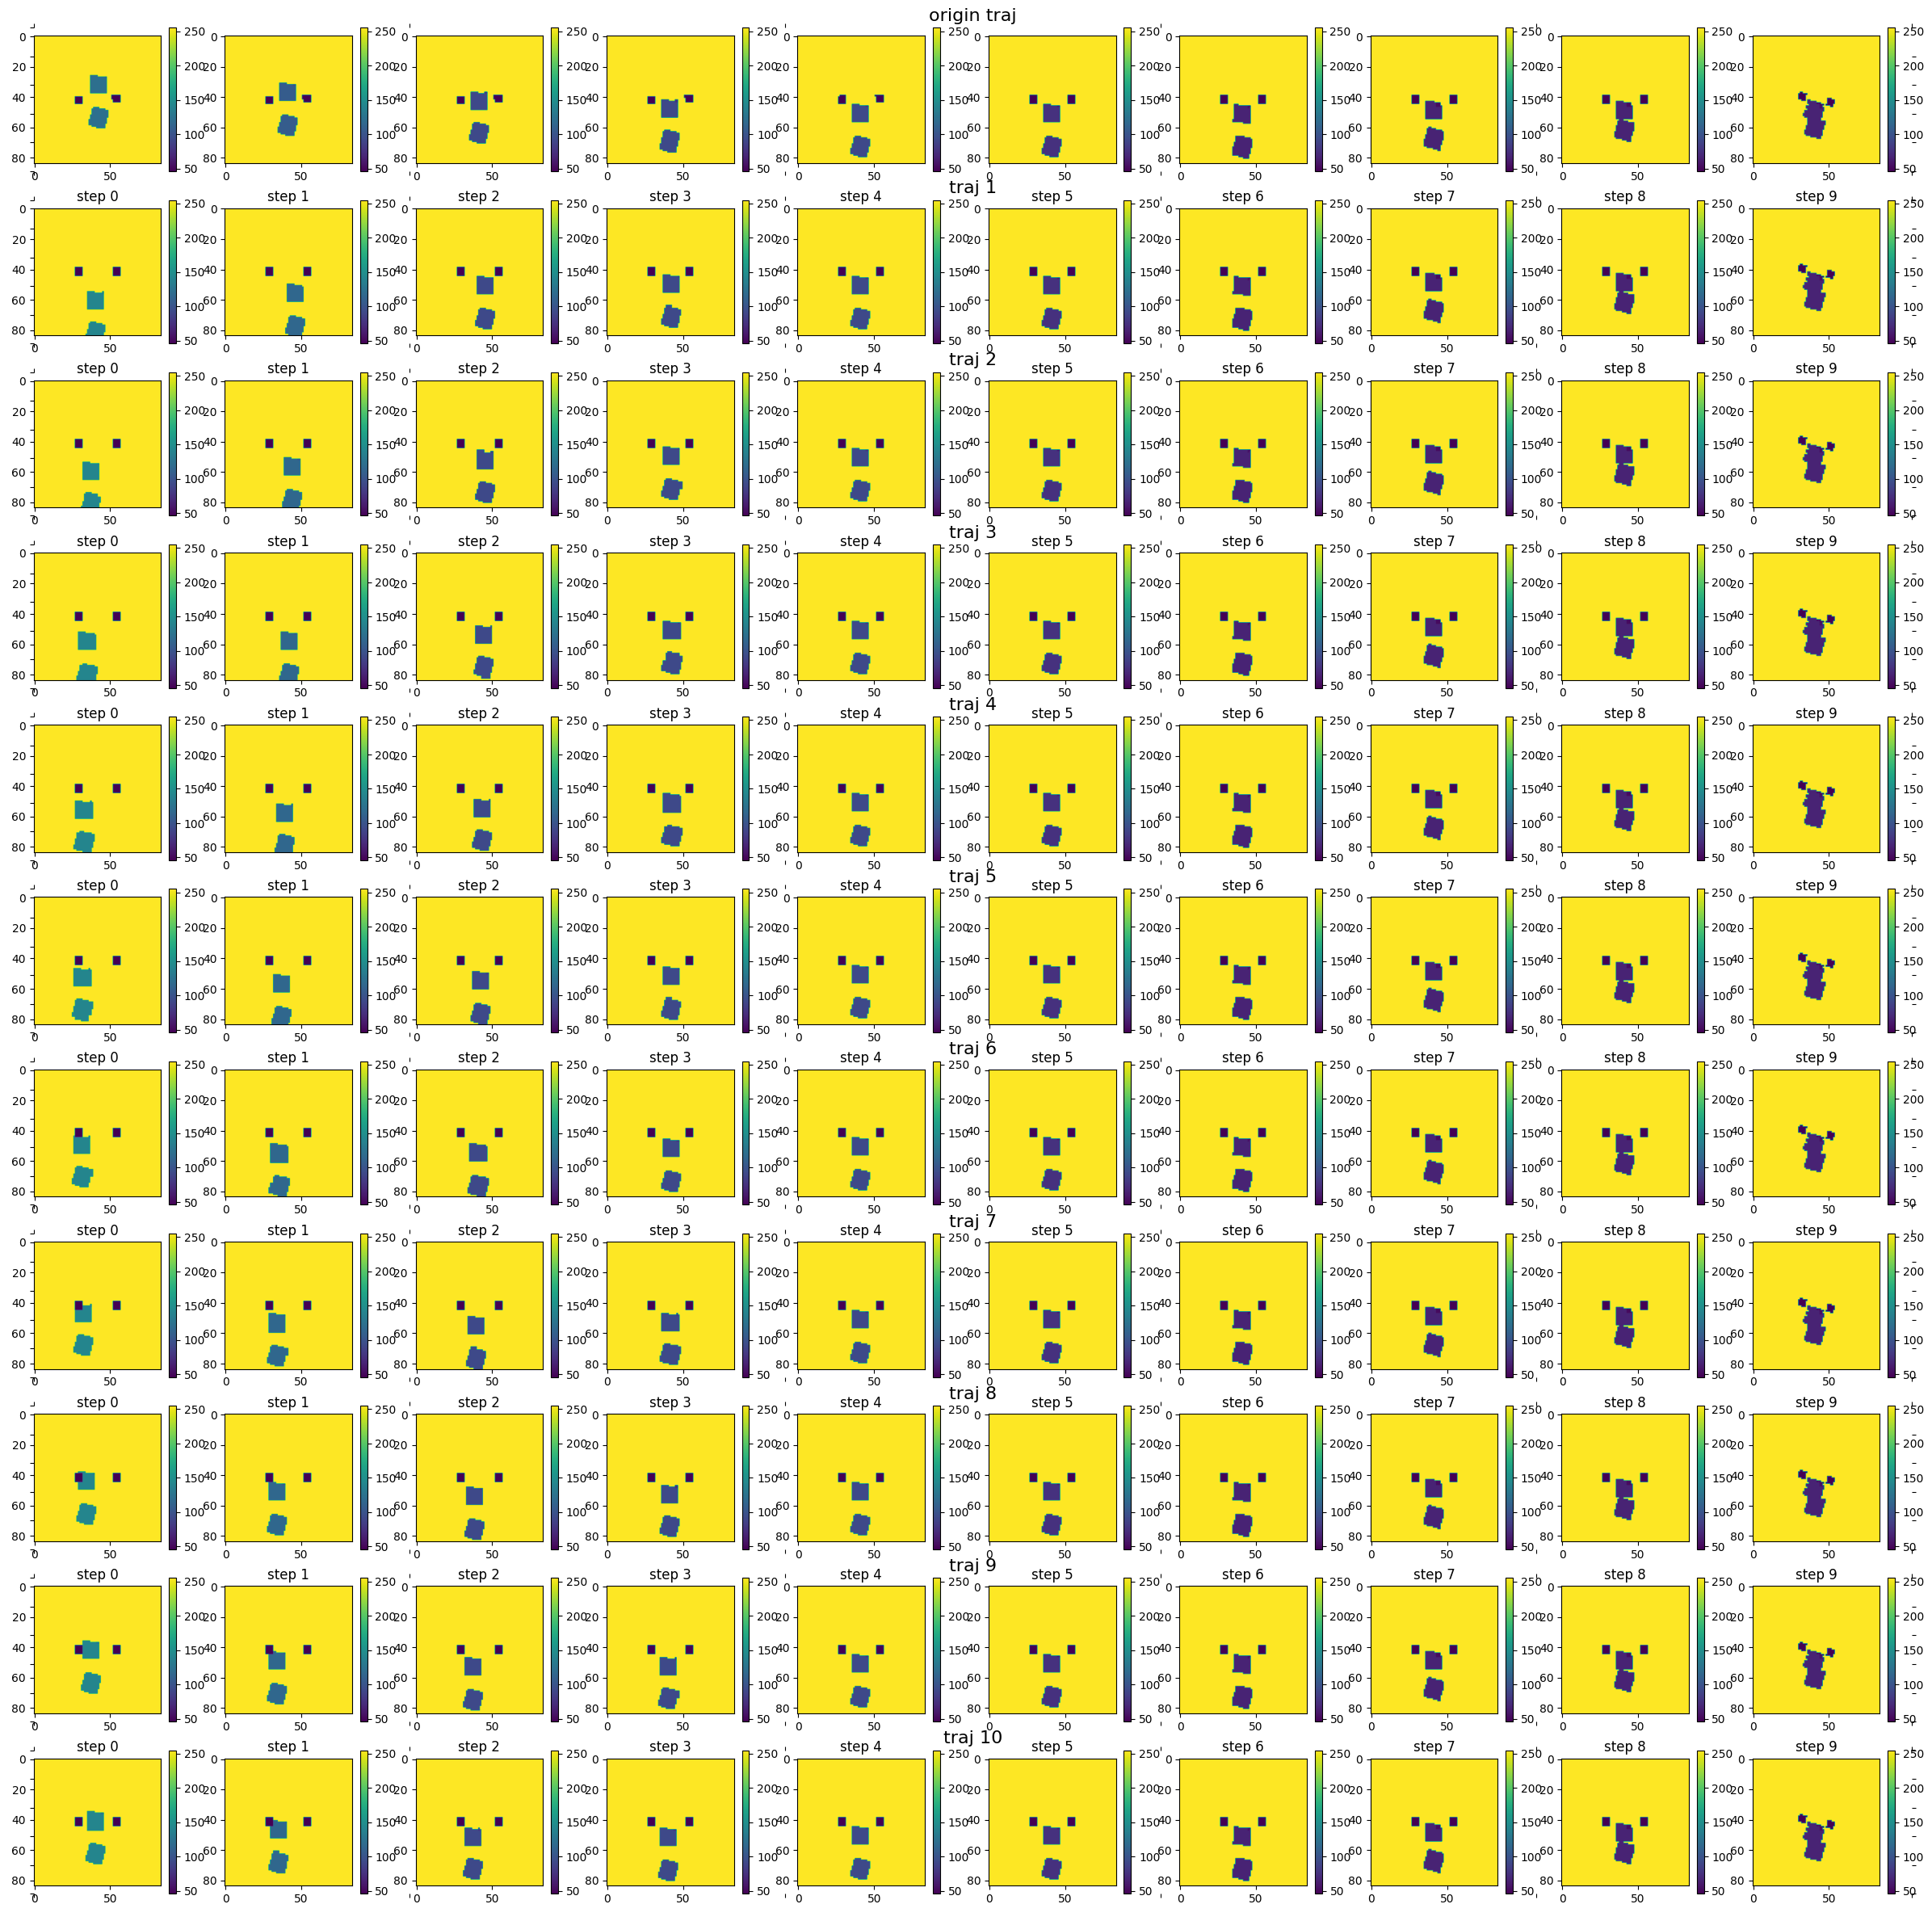

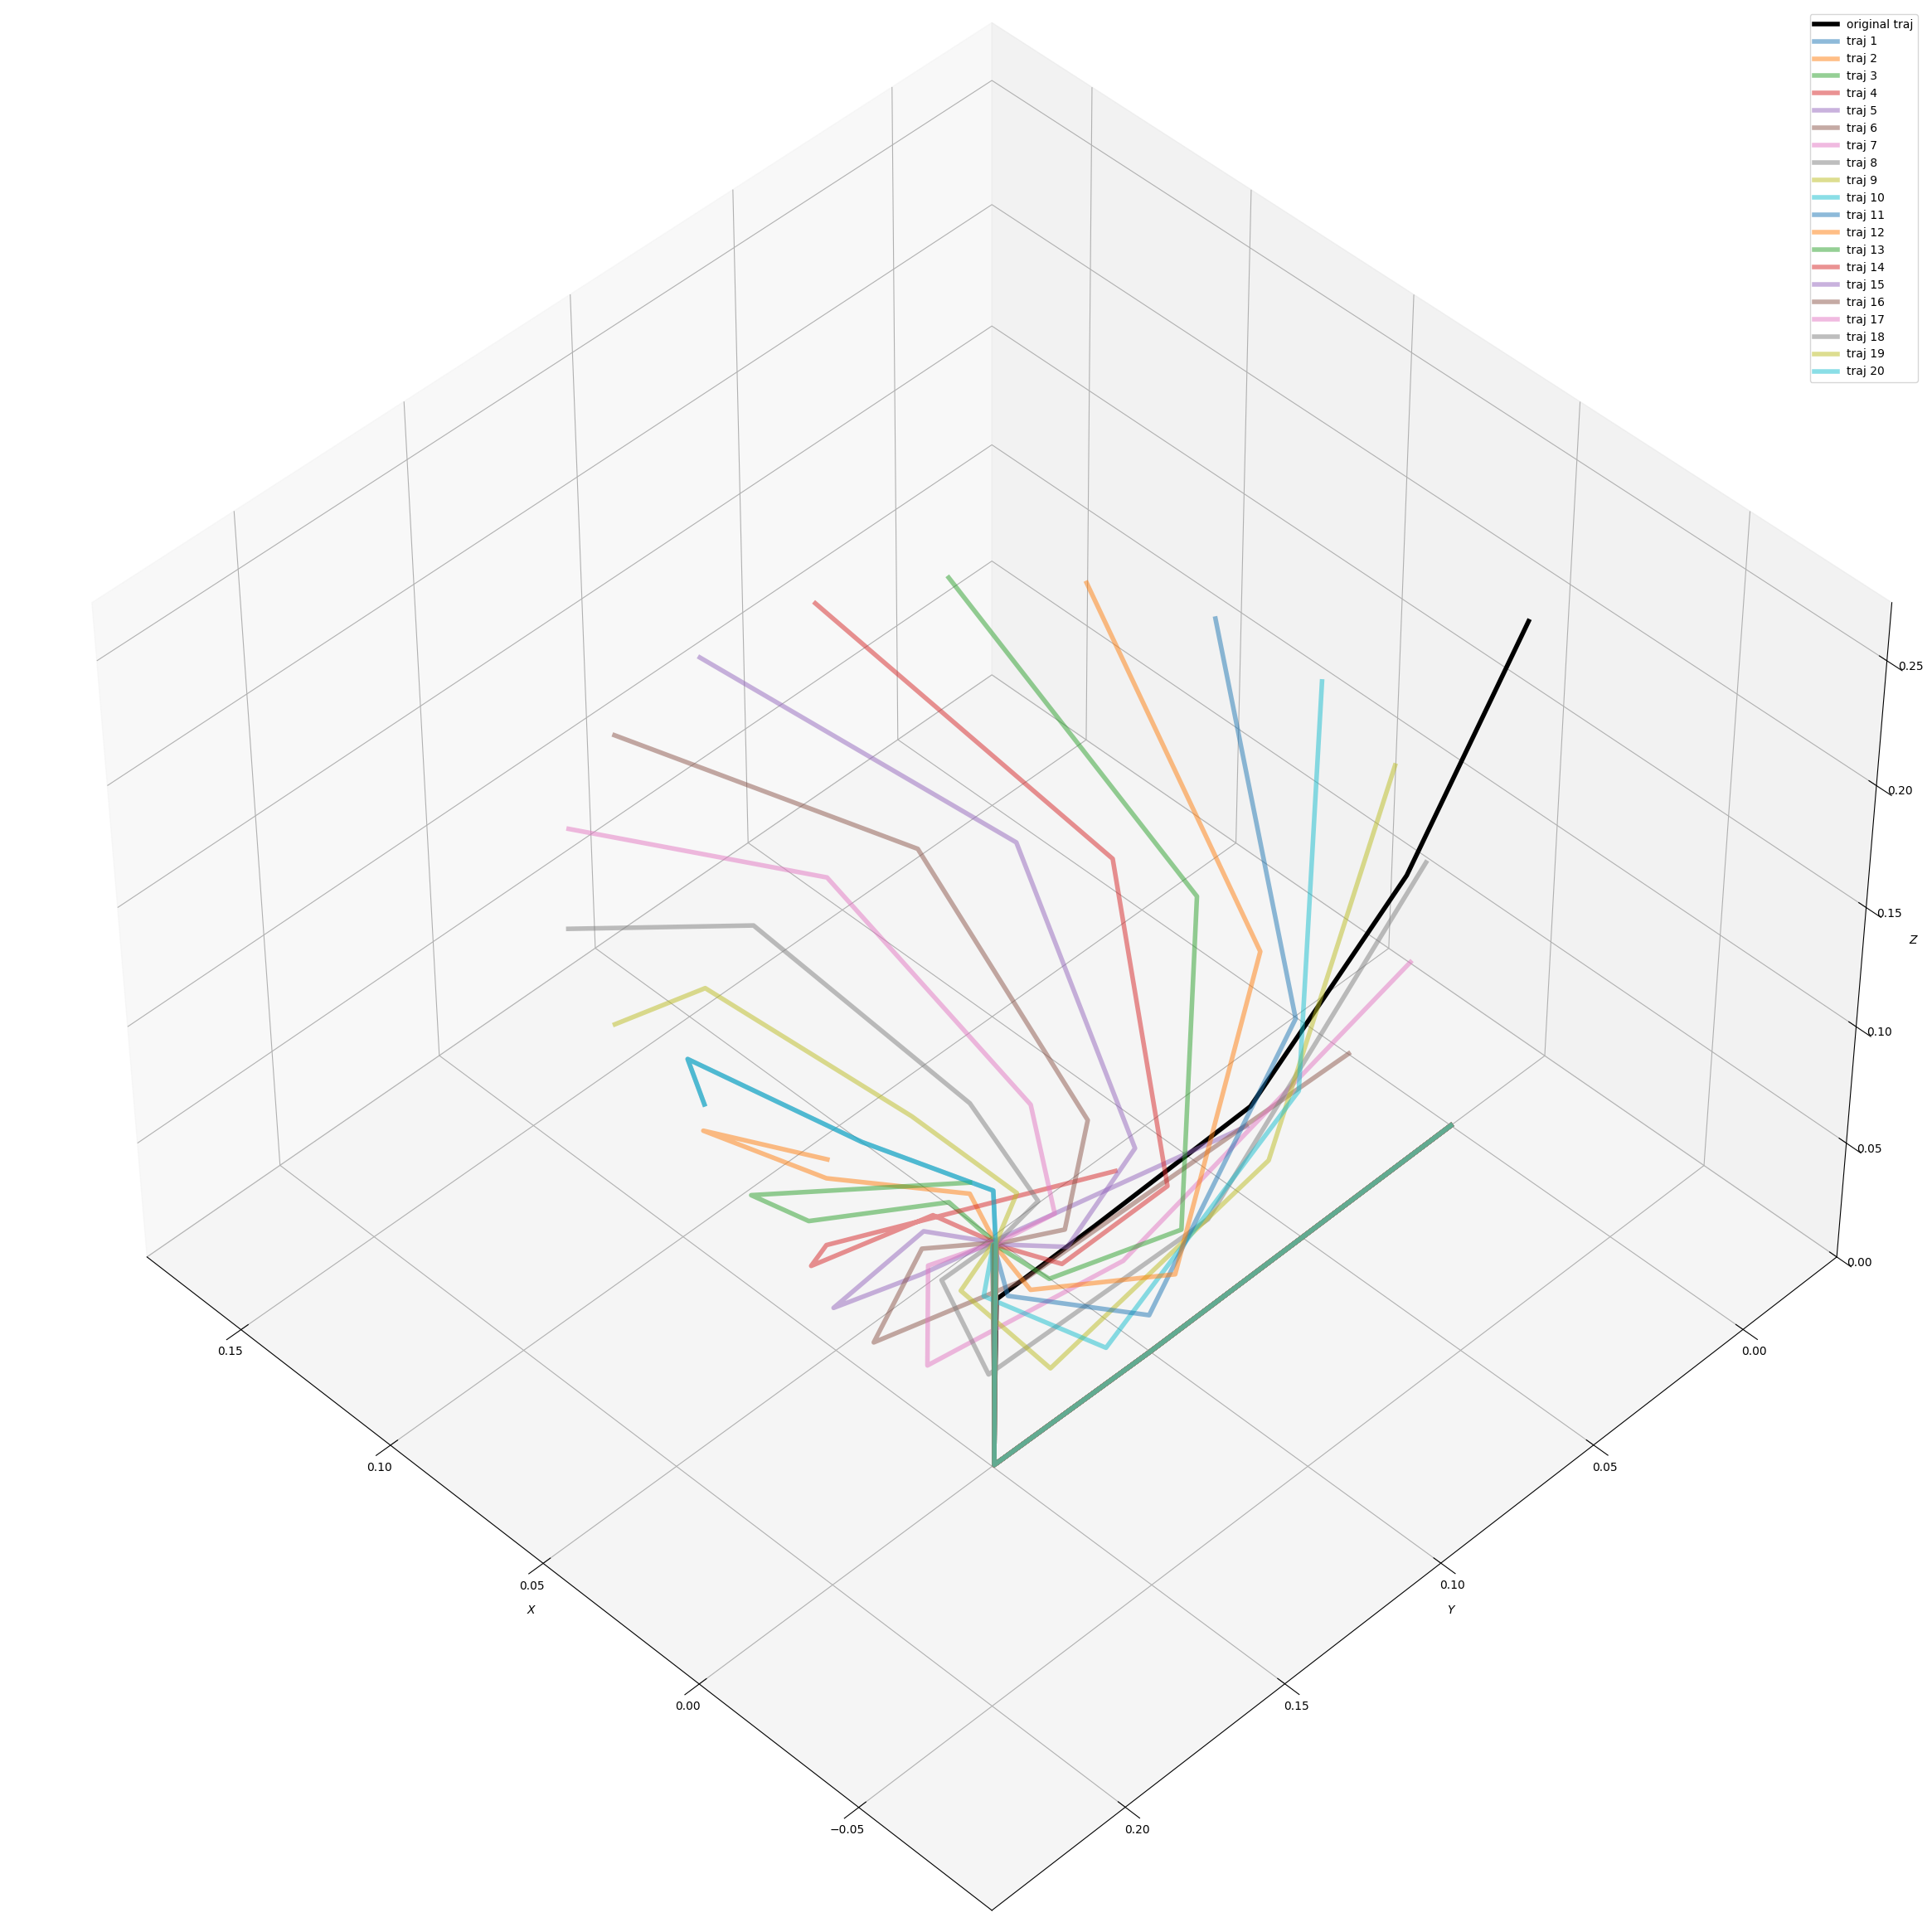

In [43]:
sym_trajs = []
sym_actions_fulls = []

oa = deepcopy(origin_actions)
trajTs = actions2Ts(
    [-a for a in reversed(origin_actions)],
    action_delta_pos=args["action_delta_pos"],
    action_delta_rot=args["action_delta_rot"],
)
traj_nums = 20
new_trajTss = []

angles = np.linspace(0, 360, num=traj_nums)
radius_ratio =0.5
height_ratio =1.5
screw_angle = 45

for traj_idx in range(traj_nums):
    new_trajTs = []
    start_idx = len(trajTs) - sym_step_idx - 1
    screw_cnt = 0
    for idx in range(len(trajTs)):
        if idx <= start_idx:
            new_trajTs.append(trajTs[idx].copy())
        else:
            origin_T = trajTs[start_idx].copy()
            current_T = trajTs[idx].copy()
            current_T[0:3, 3] = current_T[0:3, 3] - origin_T[0:3, 3]
            current_T[0:2, 3] = current_T[0:2, 3] * radius_ratio
            current_T[2, 3] = current_T[2, 3] * height_ratio
            deltaT = getT([0, 0, 0], [0, 0, angles[traj_idx] + screw_cnt * screw_angle], rot_type="euler")
            current_T = TxT([deltaT, current_T])
            current_T[0:3, 3] = current_T[0:3, 3] + origin_T[0:3, 3]
            new_trajTs.append(current_T)
            screw_cnt+=1
    new_trajTss.append(new_trajTs)


sym_trajs = [sym_depth_image_traj]
for new_trajTs in new_trajTss[:10]:
    _Ts = deepcopy(new_trajTs)
    # _Ts = [v for v in reversed(_Ts)]

    reverse_actions, exceed = Ts2actions(
        origin_T=_Ts[0],
        interval_Ts=_Ts[1:],
        action_delta_pos=args["action_delta_pos"],
        interval_gripper_states=np.zeros(len(_Ts[1:])),
        interval_oris=np.zeros(len(_Ts[1:])),
    )
    reverse_actions = [a for a in reversed(reverse_actions)]
    reverse_actions_old = [-a for a in origin_actions]
    for k in range(len(reverse_actions_old)):
        # sym_actions[0] = np.random.uniform(-1,1)
        if k>= sym_step_idx-1:
            reverse_actions[k][1] = reverse_actions_old[k][1]
            reverse_actions[k][2] =  reverse_actions_old[k][2]
            reverse_actions[k][3] =  reverse_actions_old[k][3]
        # sym_actions[k][4] = np.random.uniform(-1, 1)
    
    reverse_actions = [a for a in reversed(reverse_actions)]
    
    start_depth_dict = imgs1_meta[sym_step_idx]['depth']
    start_mask_dict = imgs1_meta[sym_step_idx]['mask']
    sym_depth_image_traj3 = local_sym_step(
        start_depth_dict, start_mask_dict, reverse_actions[len(reverse_actions)-sym_step_idx: ], K=K, reverse=False, **args
    )
    sym_depth_image_traj3 = [s for s in reversed(sym_depth_image_traj3)]
    sym_depth_image_traj3.extend(origin_depth_image_traj[sym_step_idx+1:])
    sym_trajs.append(
        [
            {"image": v, "title": f"step {j}"}
            for j, v in enumerate(sym_depth_image_traj3)
        ]
    )

points_mats = []

trajTs = actions2Ts(
    [-a for a in reversed(origin_actions)],
    action_delta_pos=args["action_delta_pos"],
    action_delta_rot=args["action_delta_rot"],
)
points_mats = []
pc_mat = {}
pc_mat["mat"] = np.array([[t[0][3], t[1][3], t[2][3]] for t in trajTs])
pc_mat["linewidth"] = 4
pc_mat["alpha"] = 1
pc_mat["label"] = f"original traj"
pc_mat["color"] = "k"
points_mats.append(pc_mat)

for i, new_trajTs in enumerate(new_trajTss):
    pc_mat = {}
    pc_mat["mat"] = np.array([[t[0][3], t[1][3], t[2][3]] for t in new_trajTs])
    pc_mat["linewidth"] = 4
    pc_mat["alpha"] = 0.5
    pc_mat["label"] = f"traj {i+1}"
    points_mats.append(pc_mat)

big_axes_title = ['origin traj']
big_axes_title.extend( [f"traj {i+1}" for i in range(len(sym_trajs)-1)])
plt.rcParams["figure.figsize"] = [30, 30]
plot_img(
    sym_trajs,
    big_axes_title=big_axes_title
)

plot_traj(points_mats, elev=45, azim=135, roll=0)